In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [107]:
#!wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv

In [108]:
df = pd.read_csv('car_fuel_efficiency.csv')
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9704 entries, 0 to 9703
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  9704 non-null   int64  
 1   num_cylinders        9222 non-null   float64
 2   horsepower           8996 non-null   float64
 3   vehicle_weight       9704 non-null   float64
 4   acceleration         8774 non-null   float64
 5   model_year           9704 non-null   int64  
 6   origin               9704 non-null   object 
 7   fuel_type            9704 non-null   object 
 8   drivetrain           9704 non-null   object 
 9   num_doors            9202 non-null   float64
 10  fuel_efficiency_mpg  9704 non-null   float64
dtypes: float64(6), int64(2), object(3)
memory usage: 834.1+ KB


In [110]:
## fill missing values
df = df.fillna(0)

In [111]:
df.isnull().sum()

engine_displacement    0
num_cylinders          0
horsepower             0
vehicle_weight         0
acceleration           0
model_year             0
origin                 0
fuel_type              0
drivetrain             0
num_doors              0
fuel_efficiency_mpg    0
dtype: int64

In [112]:
from sklearn.model_selection import train_test_split

In [113]:
df_full_train , df_test = train_test_split(df, test_size = 0.2, random_state = 1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state =1)

In [114]:
df_train = df_train.reset_index(drop =True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [115]:
df_test

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,4.0,170.0,2770.744260,16.9,2004,Europe,Diesel,Front-wheel drive,0.0,15.865949
1,230,5.0,135.0,2546.670530,11.5,2001,Europe,Gasoline,Front-wheel drive,1.0,17.885965
2,160,4.0,179.0,3845.204498,14.9,2021,Asia,Diesel,All-wheel drive,1.0,10.882701
3,230,5.0,0.0,3006.216277,14.7,2017,Europe,Diesel,All-wheel drive,0.0,14.216032
4,240,1.0,156.0,2436.633616,17.0,2015,Europe,Diesel,Front-wheel drive,1.0,18.016395
...,...,...,...,...,...,...,...,...,...,...,...
1936,200,1.0,171.0,3153.197854,16.1,2006,USA,Diesel,Front-wheel drive,1.0,14.310263
1937,220,3.0,189.0,4049.205206,16.5,2012,Asia,Gasoline,All-wheel drive,0.0,10.164457
1938,210,3.0,171.0,3500.001350,13.4,2022,Asia,Gasoline,All-wheel drive,0.0,13.354373
1939,240,2.0,238.0,2883.491696,13.7,2021,Asia,Diesel,All-wheel drive,0.0,17.038592


In [116]:
## target variable
y_train = df_train.fuel_efficiency_mpg
y_val = df_val.fuel_efficiency_mpg
y_test = df_test.fuel_efficiency_mpg

In [117]:
y_test

0       15.865949
1       17.885965
2       10.882701
3       14.216032
4       18.016395
          ...    
1936    14.310263
1937    10.164457
1938    13.354373
1939    17.038592
1940    15.026741
Name: fuel_efficiency_mpg, Length: 1941, dtype: float64

In [118]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [119]:
df_train

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors
0,120,5.0,169.0,2966.679505,13.9,2005,USA,Gasoline,Front-wheel drive,-1.0
1,200,3.0,143.0,2950.822121,17.1,2013,Asia,Diesel,Front-wheel drive,-1.0
2,180,6.0,180.0,3078.221669,17.4,2007,USA,Gasoline,All-wheel drive,0.0
3,280,5.0,174.0,2797.991793,0.0,2016,USA,Diesel,All-wheel drive,0.0
4,250,4.0,133.0,2362.426930,16.3,2010,USA,Diesel,Front-wheel drive,-1.0
...,...,...,...,...,...,...,...,...,...,...
5817,230,3.0,176.0,3430.993044,17.9,2022,Europe,Diesel,All-wheel drive,0.0
5818,250,4.0,180.0,3067.664350,15.7,2010,Asia,Diesel,All-wheel drive,-1.0
5819,230,2.0,182.0,3041.964593,16.7,2010,Europe,Diesel,All-wheel drive,0.0
5820,180,7.0,147.0,2453.341430,15.2,2015,Europe,Gasoline,All-wheel drive,0.0


In [120]:
df_test

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors
0,170,4.0,170.0,2770.744260,16.9,2004,Europe,Diesel,Front-wheel drive,0.0
1,230,5.0,135.0,2546.670530,11.5,2001,Europe,Gasoline,Front-wheel drive,1.0
2,160,4.0,179.0,3845.204498,14.9,2021,Asia,Diesel,All-wheel drive,1.0
3,230,5.0,0.0,3006.216277,14.7,2017,Europe,Diesel,All-wheel drive,0.0
4,240,1.0,156.0,2436.633616,17.0,2015,Europe,Diesel,Front-wheel drive,1.0
...,...,...,...,...,...,...,...,...,...,...
1936,200,1.0,171.0,3153.197854,16.1,2006,USA,Diesel,Front-wheel drive,1.0
1937,220,3.0,189.0,4049.205206,16.5,2012,Asia,Gasoline,All-wheel drive,0.0
1938,210,3.0,171.0,3500.001350,13.4,2022,Asia,Gasoline,All-wheel drive,0.0
1939,240,2.0,238.0,2883.491696,13.7,2021,Asia,Diesel,All-wheel drive,0.0


In [121]:
df_val

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors
0,210,6.0,151.0,2255.750322,20.9,2013,Europe,Gasoline,Front-wheel drive,-1.0
1,200,6.0,145.0,2921.328272,15.4,2008,USA,Diesel,Front-wheel drive,0.0
2,190,4.0,133.0,2357.787514,13.8,2018,Asia,Diesel,All-wheel drive,2.0
3,250,3.0,105.0,2988.730170,16.0,2012,Asia,Diesel,All-wheel drive,0.0
4,220,3.0,93.0,3174.840838,20.2,2015,Asia,Gasoline,All-wheel drive,0.0
...,...,...,...,...,...,...,...,...,...,...
1936,220,0.0,191.0,2698.807065,17.0,2006,USA,Diesel,Front-wheel drive,0.0
1937,100,2.0,0.0,3545.272512,15.5,2022,Asia,Gasoline,Front-wheel drive,1.0
1938,220,3.0,182.0,3068.941284,21.1,2012,USA,Gasoline,Front-wheel drive,0.0
1939,250,2.0,156.0,3256.003858,17.5,2003,Asia,Gasoline,All-wheel drive,1.0


In [122]:
# Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.feature_extraction import DictVectorizer

In [123]:
train_dicts = df_train.to_dict(orient = 'records')


In [124]:
dv = DictVectorizer(sparse = False)
X_train = dv.fit_transform(train_dicts)

In [125]:
dtr = DecisionTreeRegressor(max_depth=1)
dtr.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [126]:
val_dicts = df_val.to_dict(orient = 'records')
X_val = dv.transform(val_dicts)

In [127]:
y_pred = dtr.predict(X_val)

In [128]:
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score

mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

In [129]:
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")


MAE: 1.28
RMSE: 1.61
R²: 0.61


### Random Forest Regressor

In [130]:
from sklearn.ensemble import RandomForestRegressor

In [131]:
rf = RandomForestRegressor(n_estimators = 10, random_state=1, n_jobs=-1)
rf.fit(X_train, y_train)

,n_estimators,10
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [132]:
val_dicts = df_val.to_dict(orient = 'records')
X_val = dv.transform(val_dicts)

In [133]:
y_pred = rf.predict(X_val)

In [134]:
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score

mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

In [135]:
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.2f}")

MAE: 0.36
RMSE: 0.457
R²: 0.97


### Parameter Tuning

In [136]:
scores = []
# Tuning n_estimators
for n in range(10, 201, 10):
    rf = RandomForestRegressor(n_estimators = n, random_state=1)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    #print(f'n_estimators={n} --> val: {auc:.3f}')
    scores.append((n, rmse))

In [137]:
df_scores_rf = pd.DataFrame(scores, columns=['n_estimators', 'rmse'])
df_scores_rf.round(3)

,n_estimators,rmse
0,10,0.457
1,20,0.452
2,30,0.450
3,40,0.448
4,50,0.446
5,60,0.445
6,70,0.445
7,80,0.445
8,90,0.444
9,100,0.444


Text(0, 0.5, 'RMSE on Validation set')

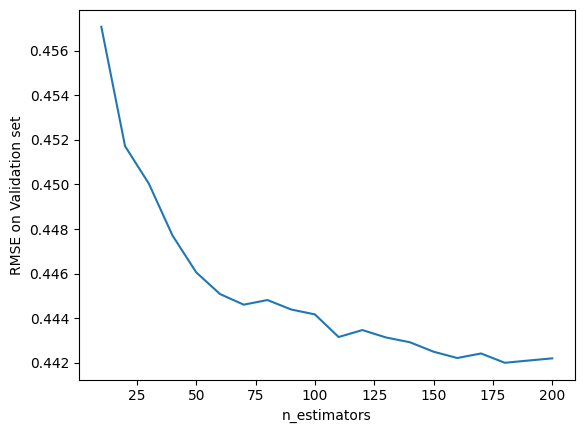

In [138]:
plt.plot(df_scores_rf.n_estimators, df_scores_rf.rmse)
plt.xlabel('n_estimators')
plt.ylabel('RMSE on Validation set')     

In [139]:
scores = []

for d in [5, 15 , 20, 25]:
    for n in range(10, 201, 10):
        rf = RandomForestRegressor(n_estimators = n, 
                                    max_depth = d,
                                    random_state=1)
        rf.fit(X_train, y_train)

        y_pred = rf.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        #print(f'n_estimators={n} --> val: {auc:.3f}')
        scores.append((d ,n,rmse))

In [140]:
columns = ['max_depth', 'n_estimators', 'rmse']
df_scores_d = pd.DataFrame(scores, columns = columns)
df_scores_d

,max_depth,n_estimators,rmse
0,5,10,0.504799
1,5,20,0.503806
2,5,30,0.502559
3,5,40,0.501773
4,5,50,0.501580
...,...,...,...
75,25,160,0.442470
76,25,170,0.442608
77,25,180,0.442148
78,25,190,0.442228


* Question 5. Feature importance

In [141]:
rf = RandomForestRegressor(n_estimators = 10,max_depth=20, random_state=1, n_jobs=-1)
rf.fit(X_train, y_train)

,n_estimators,10
,criterion,'squared_error'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [142]:
# Get feature importances
importances = rf.feature_importances_
importances

array([1.14536287e-02, 3.96650944e-04, 3.11283259e-04, 3.28170182e-03,
       3.69466267e-04, 3.01551010e-04, 1.60423301e-02, 3.16452511e-03,
       2.33145848e-03, 1.62794233e-03, 4.85137573e-04, 4.93652614e-04,
       5.64584351e-04, 9.59176087e-01])

In [143]:
feature_names = dv.get_feature_names_out() # Extract feature name from Transformed data set

In [144]:
# Create a DataFrame
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

                         Feature  Importance
13                vehicle_weight    0.959176
6                     horsepower    0.016042
0                   acceleration    0.011454
3            engine_displacement    0.003282
7                     model_year    0.003165
8                  num_cylinders    0.002331
9                      num_doors    0.001628
12                    origin=USA    0.000565
11                 origin=Europe    0.000494
10                   origin=Asia    0.000485
1     drivetrain=All-wheel drive    0.000397
4               fuel_type=Diesel    0.000369
2   drivetrain=Front-wheel drive    0.000311
5             fuel_type=Gasoline    0.000302


* vehicle_weight has the most influence among 4 features.

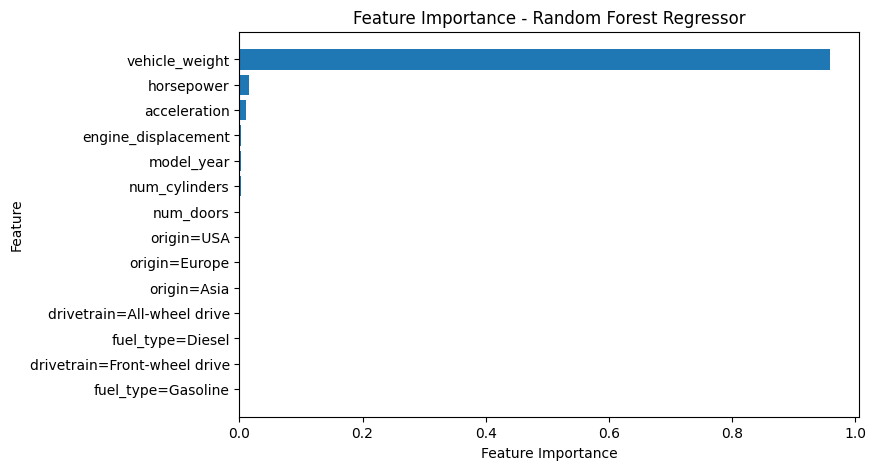

In [145]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance - Random Forest Regressor')
plt.gca().invert_yaxis()
plt.show()


### XGBoost -- 06

In [146]:
import xgboost as xgb

In [147]:
features = dv.get_feature_names_out().tolist() # call the method
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)

In [148]:
watchlist = [(dtrain, 'train'), (dval, 'val')]

In [149]:
%%capture output
xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}
model = xgb.train(xgb_params, dtrain, 
                  evals = watchlist,
                  verbose_eval= 5,
                  num_boost_round=100)

In [150]:
s = output.stdout
print(s)

[0]	train-rmse:1.81393	val-rmse:1.85444
[5]	train-rmse:0.51381	val-rmse:0.55664
[10]	train-rmse:0.37115	val-rmse:0.43896
[15]	train-rmse:0.34666	val-rmse:0.43362
[20]	train-rmse:0.33553	val-rmse:0.43376
[25]	train-rmse:0.32268	val-rmse:0.43683
[30]	train-rmse:0.31475	val-rmse:0.43752
[35]	train-rmse:0.30960	val-rmse:0.43784
[40]	train-rmse:0.30202	val-rmse:0.43968
[45]	train-rmse:0.29126	val-rmse:0.44024
[50]	train-rmse:0.28456	val-rmse:0.44140
[55]	train-rmse:0.27618	val-rmse:0.44225
[60]	train-rmse:0.26768	val-rmse:0.44290
[65]	train-rmse:0.26174	val-rmse:0.44352
[70]	train-rmse:0.25489	val-rmse:0.44531
[75]	train-rmse:0.24792	val-rmse:0.44628
[80]	train-rmse:0.24254	val-rmse:0.44689
[85]	train-rmse:0.23644	val-rmse:0.44749
[90]	train-rmse:0.23193	val-rmse:0.44839
[95]	train-rmse:0.22475	val-rmse:0.44904
[99]	train-rmse:0.21950	val-rmse:0.45018



In [151]:
%%capture output
xgb_params = {
    'eta': 0.1, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}
model = xgb.train(xgb_params, dtrain, 
                  evals = watchlist,
                  verbose_eval= 5,
                  num_boost_round=100)

In [152]:
s1 = output.stdout
print(s1)

[0]	train-rmse:2.28944	val-rmse:2.34561
[5]	train-rmse:1.41247	val-rmse:1.44988
[10]	train-rmse:0.91008	val-rmse:0.94062
[15]	train-rmse:0.63402	val-rmse:0.66672
[20]	train-rmse:0.48983	val-rmse:0.53064
[25]	train-rmse:0.41881	val-rmse:0.46891
[30]	train-rmse:0.38342	val-rmse:0.44289
[35]	train-rmse:0.36435	val-rmse:0.43250
[40]	train-rmse:0.35343	val-rmse:0.42746
[45]	train-rmse:0.34621	val-rmse:0.42595
[50]	train-rmse:0.33998	val-rmse:0.42498
[55]	train-rmse:0.33480	val-rmse:0.42449
[60]	train-rmse:0.33054	val-rmse:0.42456
[65]	train-rmse:0.32602	val-rmse:0.42493
[70]	train-rmse:0.32202	val-rmse:0.42503
[75]	train-rmse:0.31895	val-rmse:0.42526
[80]	train-rmse:0.31667	val-rmse:0.42563
[85]	train-rmse:0.31440	val-rmse:0.42574
[90]	train-rmse:0.31059	val-rmse:0.42586
[95]	train-rmse:0.30625	val-rmse:0.42611
[99]	train-rmse:0.30419	val-rmse:0.42623



In [154]:
## 0.1 eta is better here